In [1]:
#Data ingestion & memory-savvy joins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
dtypes_orders = {
    'order_id': 'int32',
    'user_id': 'int32',
    'eval_set': 'category',
    'order_number': 'int16',
    'order_dow': 'int8',
    'order_hour_of_day': 'int8',
    'days_since_prior_order': 'float32'
}
dtypes_products={
    'order_id': 'int32',
    'product_id': 'int32',
    'add_to_cart_order': 'int16',
    'reordered': 'int8'
}

orders = pd.read_csv('/kaggle/input/instacart-market-basket-analysis/orders.csv',dtype=dtypes_orders)
products_train=pd.read_csv('/kaggle/input/instacart-market-basket-analysis/order_products__train.csv',dtype=dtypes_products)
products_prior=pd.read_csv('/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv',dtype=dtypes_products)
products = pd.read_csv('/kaggle/input/instacart-market-basket-analysis/products.csv')
departments = pd.read_csv('/kaggle/input/instacart-market-basket-analysis/departments.csv')
aisles=pd.read_csv('/kaggle/input/instacart-market-basket-analysis/aisles.csv')

/kaggle/input/instacart-market-basket-analysis/products.csv
/kaggle/input/instacart-market-basket-analysis/order_products__train.csv
/kaggle/input/instacart-market-basket-analysis/orders.csv
/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv
/kaggle/input/instacart-market-basket-analysis/aisles.csv
/kaggle/input/instacart-market-basket-analysis/departments.csv


# Exploratory Data Analysis

In [2]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [3]:
orders.info()
print(orders.shape)
missing_data_orders=orders.isnull().sum()
print(missing_data_orders)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int16   
 4   order_dow               int8    
 5   order_hour_of_day       int8    
 6   days_since_prior_order  float32 
dtypes: category(1), float32(1), int16(1), int32(2), int8(2)
memory usage: 55.5 MB
(3421083, 7)
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


In [4]:
orders["eval_set"].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

In [5]:
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,3421083.0,1.710542e+06,987581.739825,1.0,855271.5,1710542.0,2565812.5,3421083.0
user_id,3421083.0,1.029782e+05,59533.717793,1.0,51394.0,102689.0,154385.0,206209.0
order_number,3421083.0,1.715486e+01,17.733164,1.0,5.0,11.0,23.0,100.0
order_dow,3421083.0,2.776219e+00,2.046829,0.0,1.0,3.0,5.0,6.0
order_hour_of_day,3421083.0,1.345202e+01,4.226088,0.0,10.0,13.0,16.0,23.0
days_since_prior_order,3214874.0,1.111483e+01,9.161989,0.0,4.0,7.0,15.0,30.0


In [6]:
products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [7]:
products_train.info()
print(products_train.shape)
missing_data_products_train=products_train.isnull().sum()
print(missing_data_products_train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int32
 1   product_id         1384617 non-null  int32
 2   add_to_cart_order  1384617 non-null  int16
 3   reordered          1384617 non-null  int8 
dtypes: int16(1), int32(2), int8(1)
memory usage: 14.5 MB
(1384617, 4)
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [8]:
products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [9]:
products_prior.info()
print(products_prior.shape)
missing_data_products_prior=products_prior.isnull().sum()
print(missing_data_products_prior)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int32
 1   product_id         int32
 2   add_to_cart_order  int16
 3   reordered          int8 
dtypes: int16(1), int32(2), int8(1)
memory usage: 340.3 MB
(32434489, 4)
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [10]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [11]:
products.info()
print(products.shape)
missing_data_products=products.isnull().sum()
print(missing_data_products)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
(49688, 4)
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


In [12]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [13]:
departments.info()
print(departments.shape)
missing_data_departments=departments.isnull().sum()
print(missing_data_departments)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
(21, 2)
department_id    0
department       0
dtype: int64


In [14]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [15]:
aisles.info()
print(aisles.shape)
missing_data_aisles=aisles.isnull().sum()
print(missing_data_aisles)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
(134, 2)
aisle_id    0
aisle       0
dtype: int64


                        Missing Values  Percentage
days_since_prior_order          206209    6.027594


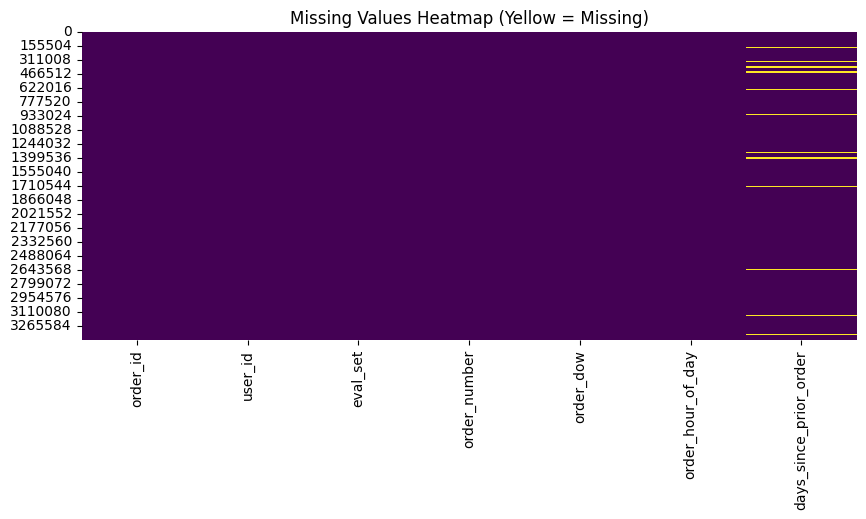

In [16]:
# 1. Calculate missing percentages
missing_data = pd.DataFrame({
    'Missing Values': orders.isnull().sum(),
    'Percentage': (orders.isnull().sum() / len(orders)) * 100
})
print(missing_data[missing_data['Missing Values'] > 0])

# 2. Visualize missing values
plt.figure(figsize=(10,4))
sns.heatmap(orders.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.show()

**Distribution Plots**

This plot shows the distribution of days between consecutive orders
Most users place their next order within a short period, indicating frequent purchasing behavior

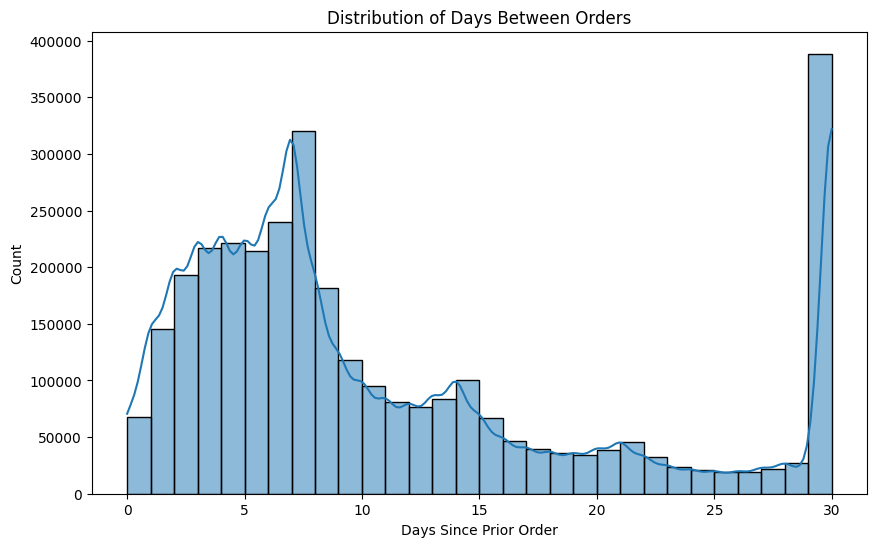

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30, kde=True)
plt.title('Distribution of Days Between Orders')
plt.xlabel('Days Since Prior Order')
plt.show()

**Distribution of Reordered Flag**

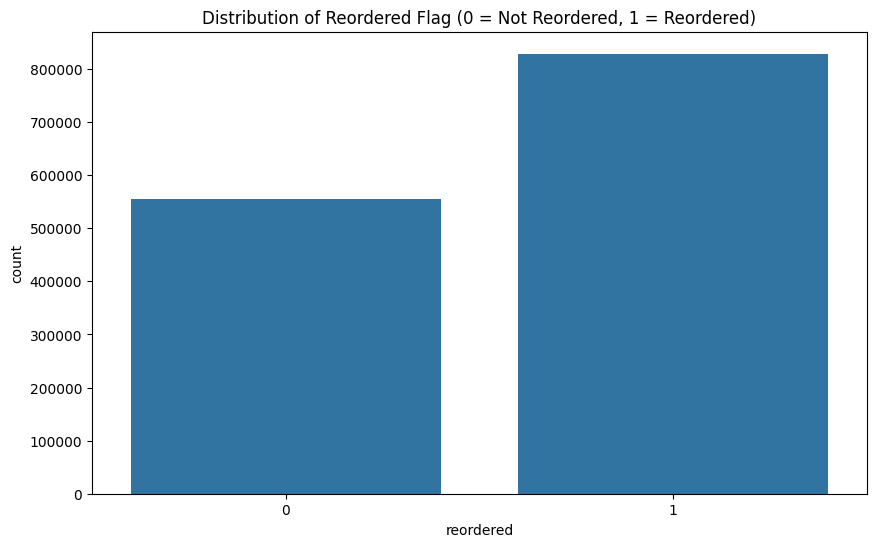

Class imbalance: Not Reordered = 40.14%, Reordered = 59.86%


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(x='reordered', data=products_train)
plt.title('Distribution of Reordered Flag (0 = Not Reordered, 1 = Reordered)')
plt.show()
imbalance_ratio = products_train['reordered'].value_counts(normalize=True)
print(f"Class imbalance: Not Reordered = {imbalance_ratio[0]:.2%}, Reordered = {imbalance_ratio[1]:.2%}")

**Top-k Frequent Categories**

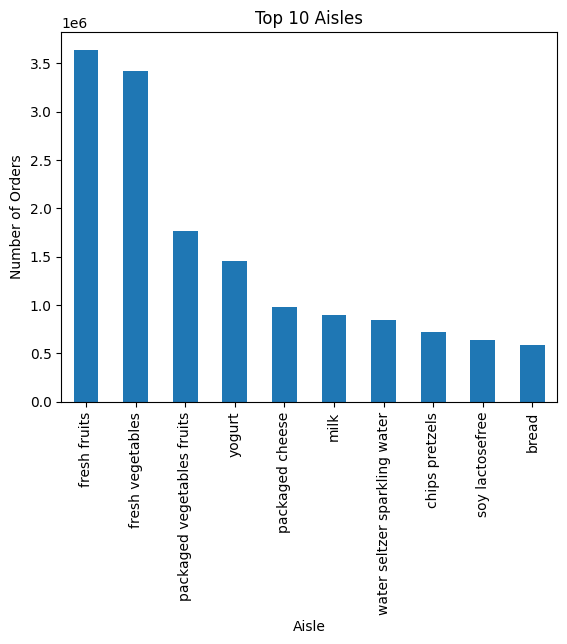

In [19]:
#Top 10 Aisles
orders_products_merged = products_prior.merge(
    products[['product_id', 'aisle_id']],
    on='product_id',
    how='left'
)

orders_with_aisle = orders_products_merged.merge(
    aisles,
    on='aisle_id',
    how='left'
)

aisle_counts = orders_with_aisle['aisle'].value_counts()

top_10_aisles = aisle_counts.head(10)

top_10_aisles.plot(kind='bar')
plt.title('Top 10 Aisles')
plt.xlabel('Aisle')
plt.ylabel('Number of Orders')
plt.show()

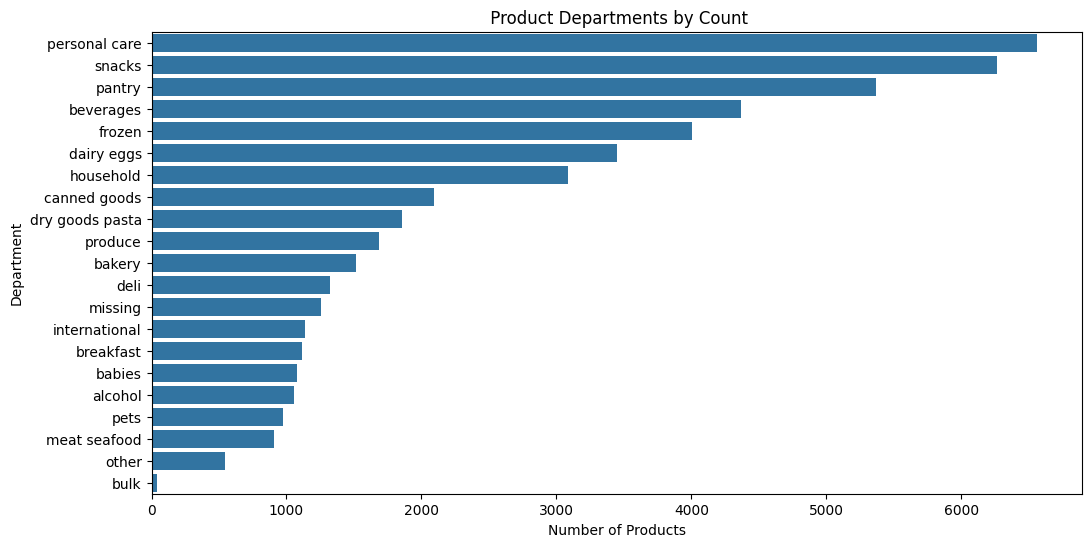

In [20]:
#Top Departments
products_dept = products.merge(departments, on='department_id')
dept_counts = products_dept['department'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(
    x=dept_counts.values,
    y=dept_counts.index
)
plt.title(' Product Departments by Count')
plt.xlabel('Number of Products')
plt.ylabel('Department')
plt.show()

**Correlation Analysis**

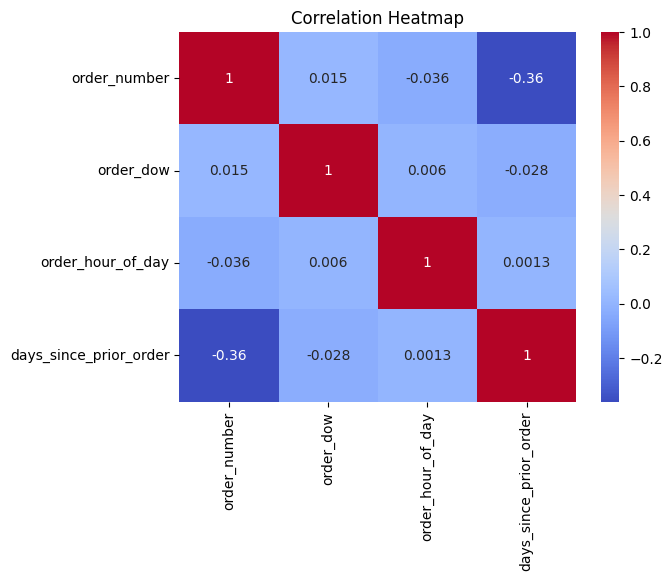

In [21]:
#Heatmap
numeric_df=orders[['order_number','order_dow'
,'order_hour_of_day'
,'days_since_prior_order']]
corr=numeric_df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

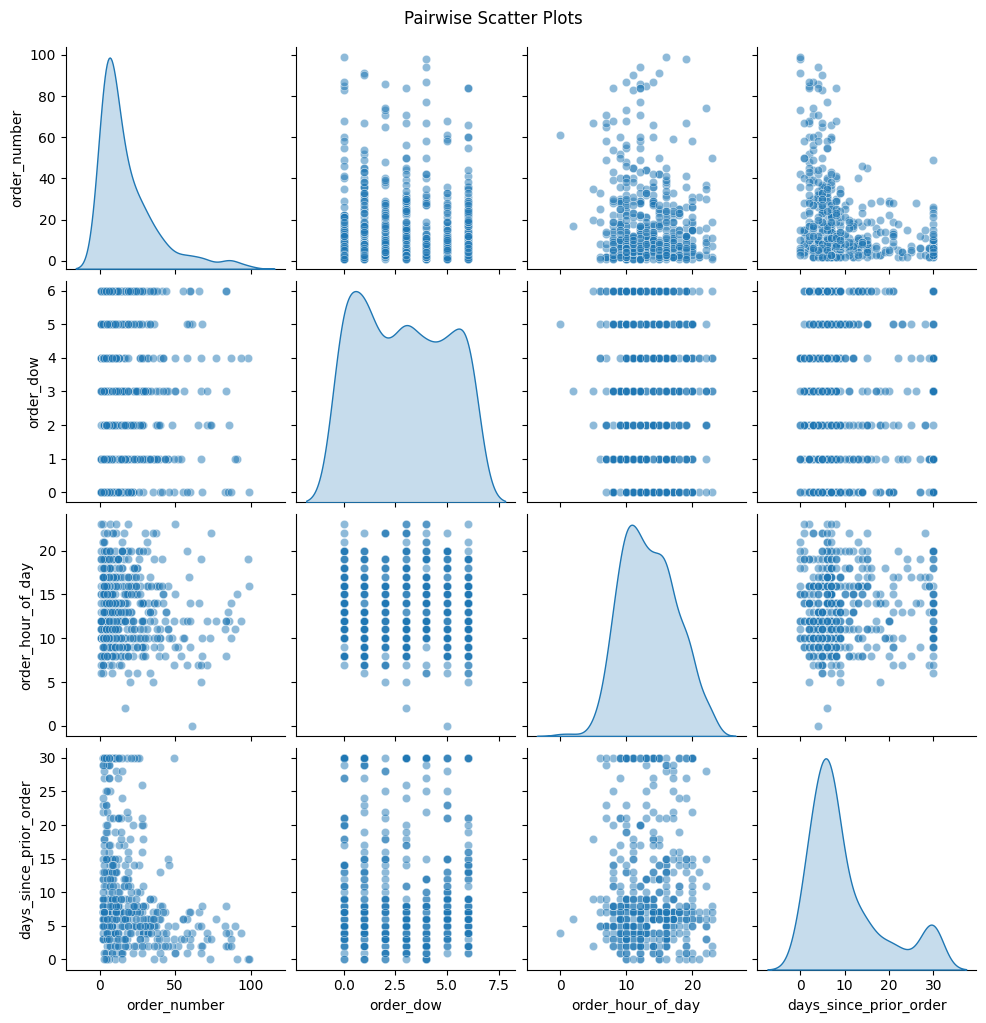

In [22]:
#pairwise scatter plots
sns.pairplot(numeric_df.sample(500), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Scatter Plots', y=1.02)
plt.show()

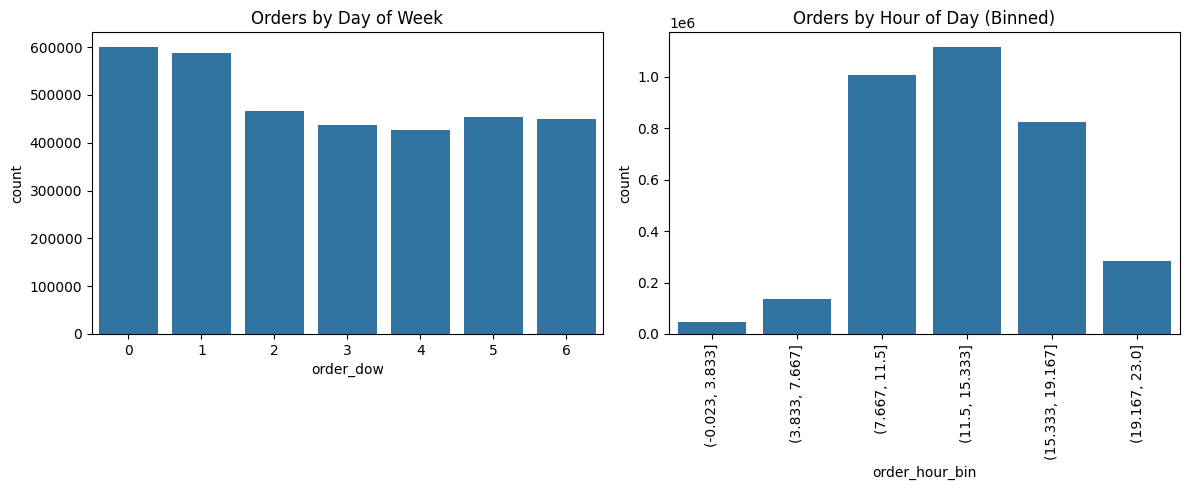

In [23]:
#day-of-week
orders['order_hour_bin'] = pd.cut(orders['order_hour_of_day'], bins=6)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x='order_dow', data=orders)
plt.title('Orders by Day of Week')

#time-of-day
plt.subplot(1,2,2)
sns.countplot(x='order_hour_bin', data=orders)
plt.title('Orders by Hour of Day (Binned)')
plt.xticks(rotation=90)
plt.tight_layout() 
plt.show()

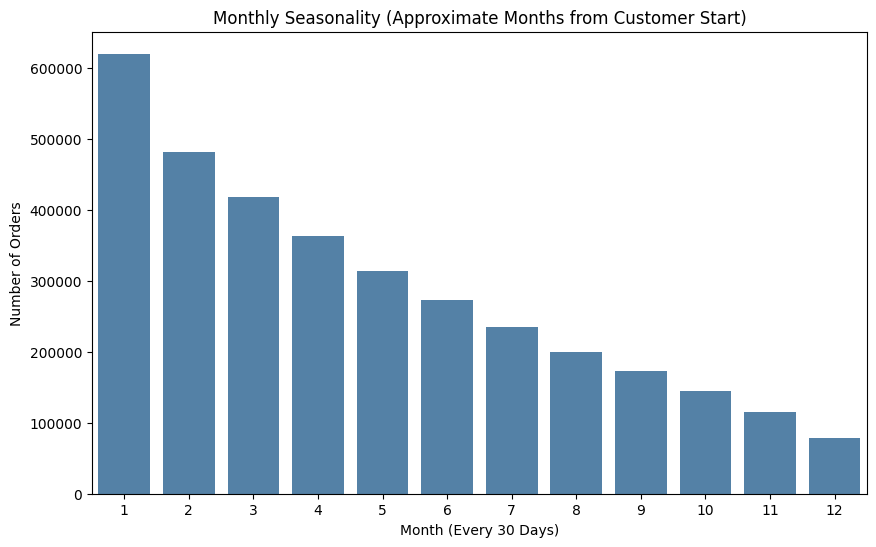

In [24]:
#monthly seasonality plots
orders['cum_days'] = orders.groupby('user_id')['days_since_prior_order'].cumsum().fillna(0)

orders['month_proxy'] = (orders['cum_days'] // 30).astype(int) + 1

plt.figure(figsize=(10, 6))
sns.countplot(data=orders[orders['month_proxy'] <= 12], x='month_proxy', color='steelblue')
plt.title('Monthly Seasonality (Approximate Months from Customer Start)')
plt.xlabel('Month (Every 30 Days)')
plt.ylabel('Number of Orders')
plt.show()

# Cleaning & Imputation 

In [25]:
#Handle Missing Values
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0) #better optin
#or 
#orders_with_median = orders['days_since_prior_order'].median()
#orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(orders_with_median)

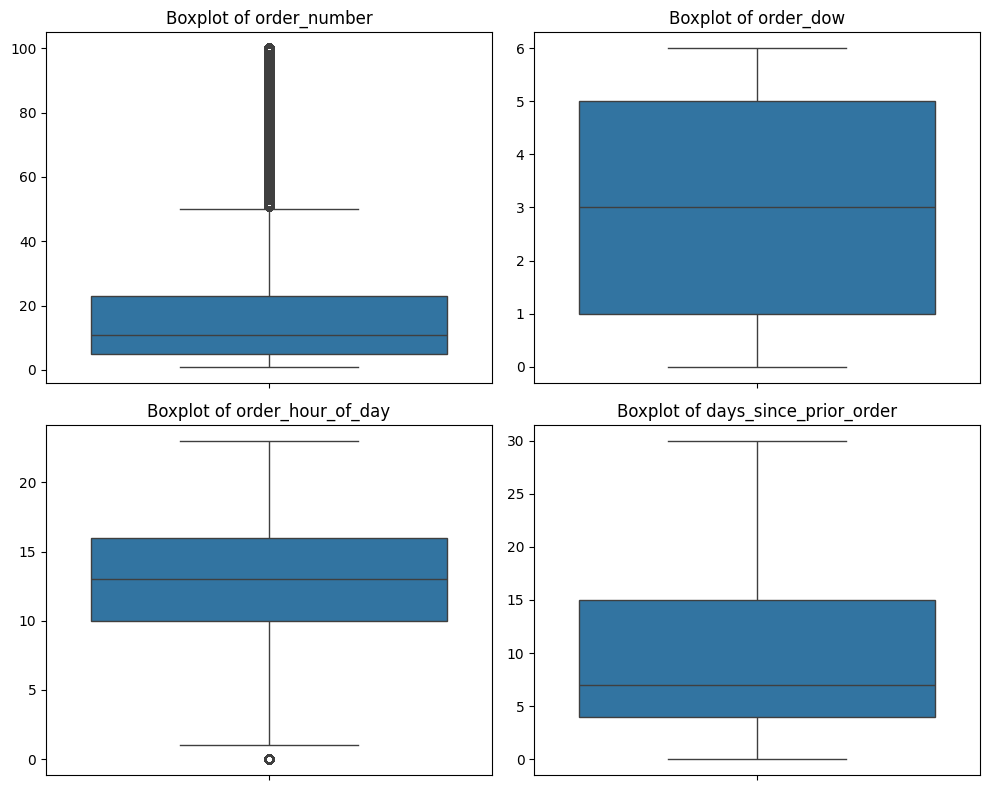

In [26]:
#Outlier Detection By Using Boxplot
#before treatment
numeric_features = ['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=orders[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [27]:
#Outlier treatment
top_value = orders['order_number'].quantile(0.95)
orders['order_number'] = orders['order_number'].clip(upper=top_value)

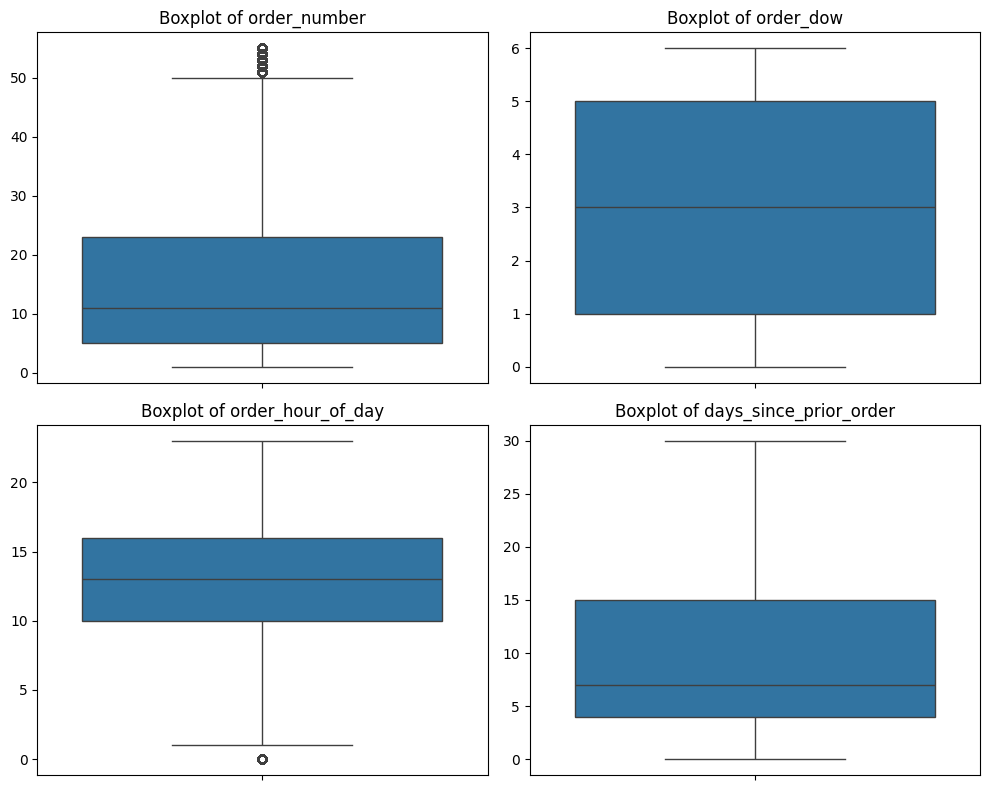

In [28]:
#After treatment
numeric_features = ['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=orders[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [29]:
# Split orders
orders_prior_only = orders.loc[orders['eval_set'] == 'prior']
orders_train_only = orders.loc[orders['eval_set'] == 'train']

# Prior orders
products_prior_full = products_prior.merge(
    orders_prior_only, 
    on='order_id', 
    how='inner'
)
products_prior_full = products_prior_full.merge(
    products, 
    on='product_id', 
    how='left', 
    suffixes=('', '_prod')
)
products_prior_full = products_prior_full.merge(aisles, on='aisle_id', how='left')
products_prior_full = products_prior_full.merge(departments, on='department_id', how='left')

# Train orders
products_train = products_train.rename(columns={'reordered': 'target'}, errors='ignore')
orders_train = products_train.merge(orders_train_only, on='order_id', how='inner')
orders_train = orders_train.merge(
    products,
    on='product_id', 
    how='left', 
    suffixes=('', '_prod')
)
orders_train = orders_train.merge(aisles, on='aisle_id', how='left')
orders_train = orders_train.merge(departments, on='department_id', how='left')

# Feature Engineering

In [30]:
# User features
user_features = (
    orders_prior_only.groupby('user_id')['order_number']
    .max()
    .to_frame('u_total_orders')
    .reset_index()
)
user_days = (
    orders_prior_only.groupby('user_id')['days_since_prior_order']
    .mean()
    .to_frame('u_avg_days_between')
    .reset_index()
)

user_df = user_features.merge(user_days, on='user_id', how='left',suffixes=('', '_days'))

# Train data
orders_train = orders_train.merge(user_df, on='user_id', how='left',suffixes=('', '_user'))

In [31]:
# Product features
prod_count = (
    products_prior.groupby('product_id')['order_id']
    .count()
    .to_frame('p_total_purchases')
    .reset_index()
)
prod_reorder_rate = (
    products_prior.groupby('product_id')['reordered']
    .mean()
    .to_frame('p_reorder_rate')
    .reset_index()
)
prod_pos = (
    products_prior.groupby('product_id')['add_to_cart_order']
    .mean()
    .to_frame('p_avg_pos_cart')
    .reset_index()
)

product_features = prod_count.merge(prod_reorder_rate, on='product_id', how='left')
product_features = product_features.merge(prod_pos, on='product_id', how='left')

# Merge into train data
orders_train = orders_train.merge(product_features, on='product_id', how='left')

In [32]:
# User-Product Features
user_product_counts = (
    products_prior_full
    .groupby(['user_id', 'product_id'])['order_id']
    .count()
    .reset_index()
)
user_product_counts.columns = ['user_id', 'product_id', 'user_product_purchase_count']

orders_train = orders_train.merge(
    user_product_counts, 
    on=['user_id', 'product_id'], 
    how='left'
)

print(orders_train[['user_id', 'product_id', 'user_product_purchase_count']].head())

   user_id  product_id  user_product_purchase_count
0   112108       49302                          2.0
1   112108       11109                          2.0
2   112108       10246                          NaN
3   112108       49683                          NaN
4   112108       43633                          2.0


In [33]:
# Aggregations over windows
products_prior_full['order_rank'] = products_prior_full.groupby(['user_id', 'product_id']).cumcount(ascending=False)
products_prior_full['is_in_last_3'] = (products_prior_full['order_rank'] < 3)
products_prior_full.drop(columns=['order_rank'], inplace=True)

user_product_last3 = (
    products_prior_full[['user_id', 'product_id', 'is_in_last_3']]
    .groupby(['user_id','product_id'])['is_in_last_3']
    .max()   
    .reset_index()
)

#train_data
orders_train = orders_train.merge(user_product_last3, on=['user_id','product_id'], how='left')

print(orders_train[['user_id','product_id','is_in_last_3']].head())

   user_id  product_id is_in_last_3
0   112108       49302         True
1   112108       11109         True
2   112108       10246          NaN
3   112108       49683          NaN
4   112108       43633         True


In [34]:
# Temporal feature
products_prior_full['is_weekend'] = products_prior_full['order_dow'].isin([0, 6])

last_3 = products_prior_full.groupby('user_id').tail(3)

recent_reorder = (
    last_3.groupby('user_id')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'u_recent_reorder_rate'})
)

orders_train = orders_train.merge(recent_reorder, on='user_id', how='left')

print(orders_train[['user_id','u_recent_reorder_rate']].head())

   user_id  u_recent_reorder_rate
0   112108                    0.0
1   112108                    0.0
2   112108                    0.0
3   112108                    0.0
4   112108                    0.0


In [35]:
orders_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   order_id                     1384617 non-null  int32   
 1   product_id                   1384617 non-null  int32   
 2   add_to_cart_order            1384617 non-null  int16   
 3   target                       1384617 non-null  int8    
 4   user_id                      1384617 non-null  int32   
 5   eval_set                     1384617 non-null  category
 6   order_number                 1384617 non-null  int16   
 7   order_dow                    1384617 non-null  int8    
 8   order_hour_of_day            1384617 non-null  int8    
 9   days_since_prior_order       1384617 non-null  float32 
 10  order_hour_bin               1384617 non-null  category
 11  cum_days                     1384617 non-null  float32 
 12  month_proxy                 

In [36]:
#Non-linear feature
orders_train['log_total_orders'] = np.log1p(orders_train['u_total_orders'])

In [37]:
for var in ['orders', 'products_prior', 'products', 'aisles', 'departments']:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

63873

In [38]:
orders_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 27 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   order_id                     1384617 non-null  int32   
 1   product_id                   1384617 non-null  int32   
 2   add_to_cart_order            1384617 non-null  int16   
 3   target                       1384617 non-null  int8    
 4   user_id                      1384617 non-null  int32   
 5   eval_set                     1384617 non-null  category
 6   order_number                 1384617 non-null  int16   
 7   order_dow                    1384617 non-null  int8    
 8   order_hour_of_day            1384617 non-null  int8    
 9   days_since_prior_order       1384617 non-null  float32 
 10  order_hour_bin               1384617 non-null  category
 11  cum_days                     1384617 non-null  float32 
 12  month_proxy                 

# Encoding Categorical Variables

### 1. One-Hot Encoding (OHE)
Objective:Transform low-cardinality categorical variables into binary features (0 and 1).

Why `order_dow`?
Low Cardinality:** This column has only 7 unique values (days of the week). Using OHE here is efficient and won't cause a "Dimensionality Explosion."
No Ordinal Relationship:** Days of the week don't have a mathematical ranking (Day 6 is not "greater" than Day 1). OHE ensures the model treats each day as a separate independent category, which is ideal for models like Logistic Regression.

In [39]:
# Define bins and labels
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']

orders_train['hour_bin'] = pd.cut(orders_train['order_hour_of_day'], bins=bins, labels=labels, right=False)

train_data = pd.get_dummies(orders_train, columns=['hour_bin', 'order_dow'], drop_first=True)

print(orders_train.head())
print(orders_train.shape)

   order_id  product_id  add_to_cart_order  target  user_id eval_set  \
0         1       49302                  1       1   112108    train   
1         1       11109                  2       1   112108    train   
2         1       10246                  3       0   112108    train   
3         1       49683                  4       0   112108    train   
4         1       43633                  5       1   112108    train   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  ...  \
0             4          4                 10                     9.0  ...   
1             4          4                 10                     9.0  ...   
2             4          4                 10                     9.0  ...   
3             4          4                 10                     9.0  ...   
4             4          4                 10                     9.0  ...   

  u_total_orders  u_avg_days_between  p_total_purchases p_reorder_rate  \
0              3        

In [40]:
orders_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 28 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   order_id                     1384617 non-null  int32   
 1   product_id                   1384617 non-null  int32   
 2   add_to_cart_order            1384617 non-null  int16   
 3   target                       1384617 non-null  int8    
 4   user_id                      1384617 non-null  int32   
 5   eval_set                     1384617 non-null  category
 6   order_number                 1384617 non-null  int16   
 7   order_dow                    1384617 non-null  int8    
 8   order_hour_of_day            1384617 non-null  int8    
 9   days_since_prior_order       1384617 non-null  float32 
 10  order_hour_bin               1384617 non-null  category
 11  cum_days                     1384617 non-null  float32 
 12  month_proxy                 

### 2. Target Encoding 
Objective: Replace high-cardinality IDs with the mean of the target variable (`reordered`), representing the "probability" of a reorder.

Why `product_id` and `user_id`?
High Cardinality: These columns contain thousands of unique IDs. One-Hot Encoding would create a massive, sparse matrix that crashes the memory.



In [41]:
from sklearn.model_selection import KFold

# 1. First, calculate GLOBAL mean from PRIOR data
global_mean = products_prior_full['reordered'].mean()

# 2. Create K-fold encoding (prevents leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
orders_train['user_target_enc'] = 0.0
orders_train['product_target_enc'] = 0.0

for train_idx, val_idx in kf.split(orders_train):
    # Get training fold
    train_fold = orders_train.iloc[train_idx]
    
    # Combine training fold with PRIOR data
    user_data = pd.concat([
        products_prior_full[['user_id', 'reordered']],
        train_fold[['user_id', 'target']].rename(columns={'target': 'reordered'})
    ])
    
    product_data = pd.concat([
        products_prior_full[['product_id', 'reordered']],
        train_fold[['product_id', 'target']].rename(columns={'target': 'reordered'})
    ])
    
    # Calculate MEANS with SMOOTHING
    user_means = user_data.groupby('user_id')['reordered'].agg(['count', 'mean'])
    user_means['smoothed'] = (user_means['count'] * user_means['mean'] + 10 * global_mean) / (user_means['count'] + 10)
    
    product_means = product_data.groupby('product_id')['reordered'].agg(['count', 'mean'])
    product_means['smoothed'] = (product_means['count'] * product_means['mean'] + 10 * global_mean) / (product_means['count'] + 10)
    
    # Apply to validation fold
    orders_train.loc[val_idx, 'user_target_enc'] = orders_train.loc[val_idx, 'user_id'].map(user_means['smoothed'])
    orders_train.loc[val_idx, 'product_target_enc'] = orders_train.loc[val_idx, 'product_id'].map(product_means['smoothed'])

# 3. Fill any missing values with global mean
orders_train['user_target_enc'].fillna(global_mean, inplace=True)
orders_train['product_target_enc'].fillna(global_mean, inplace=True)

print(orders_train[['user_id', 'user_target_enc', 'product_id', 'product_target_enc']].head())

   user_id  user_target_enc  product_id  product_target_enc
0   112108         0.469360       49302            0.630709
1   112108         0.469360       11109            0.714108
2   112108         0.469360       10246            0.525237
3   112108         0.510729       49683            0.692009
4   112108         0.470973       43633            0.476389


/tmp/ipykernel_184/1273469540.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_train['user_target_enc'].fillna(global_mean, inplace=True)
/tmp/ipykernel_184/1273469540.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

 ### 3. Frequency Encoding
Objective: Replace a category with its frequency (count) in the dataset.

Why `aisle_id` and `department_id`? 
Popularity Proxy: Replacing an aisle ID with its count acts as a proxy for "Popularity." It tells the model which aisles or departments have higher traffic.
Dimension Reduction: It keeps the information in a single column instead of expanding it into 134 separate columns (in the case of aisles), satisfying the "Memory Optimization" requirement.
Interpretability: It is easier to interpret than Hashing, as higher values directly correspond to more frequent categories.

In [42]:
aisle_freq = products_prior_full['aisle_id'].value_counts()
dept_freq = products_prior_full['department_id'].value_counts()

orders_train['aisle_freq_enc'] = orders_train['aisle_id'].map(dept_freq)
orders_train['dept_freq_enc'] = orders_train['department_id'].map(dept_freq)

print(orders_train[['aisle_id', 'aisle_freq_enc', 'department_id', 'dept_freq_enc']].head())

   aisle_id  aisle_freq_enc  department_id  dept_freq_enc
0       120             NaN             16        5414016
1       108             NaN             16        5414016
2        83             NaN              4        9479291
3        83             NaN              4        9479291
4        95             NaN             15        1068058


In [43]:
orders_train.isnull().sum()

order_id                             0
product_id                           0
add_to_cart_order                    0
target                               0
user_id                              0
eval_set                             0
order_number                         0
order_dow                            0
order_hour_of_day                    0
days_since_prior_order               0
order_hour_bin                       0
cum_days                             0
month_proxy                          0
product_name                         0
aisle_id                             0
department_id                        0
aisle                                0
department                           0
u_total_orders                       0
u_avg_days_between                   0
p_total_purchases                    9
p_reorder_rate                       9
p_avg_pos_cart                       9
user_product_purchase_count     555793
is_in_last_3                    555793
u_recent_reorder_rate    

In [44]:
# Handle Missing Values
# count columns 
orders_train['user_product_purchase_count'] = orders_train['user_product_purchase_count'].fillna(0)
orders_train['p_total_purchases'] = orders_train['p_total_purchases'].fillna(0)

# flag columns
orders_train['is_in_last_3'] = orders_train['is_in_last_3'].fillna(0)

# rate/average/target columns 
rate_columns = [
    'p_reorder_rate',
    'p_avg_pos_cart', 
    'u_avg_days_between',
    'u_recent_reorder_rate',
    'aisle_freq_enc',
    'product_target_enc'
]

for col in rate_columns:
    orders_train[col] = orders_train[col].fillna(orders_train[col].mean())

In [45]:
orders_train.isnull().sum()

order_id                       0
product_id                     0
add_to_cart_order              0
target                         0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order         0
order_hour_bin                 0
cum_days                       0
month_proxy                    0
product_name                   0
aisle_id                       0
department_id                  0
aisle                          0
department                     0
u_total_orders                 0
u_avg_days_between             0
p_total_purchases              0
p_reorder_rate                 0
p_avg_pos_cart                 0
user_product_purchase_count    0
is_in_last_3                   0
u_recent_reorder_rate          0
log_total_orders               0
hour_bin                       0
user_target_enc                0
product_target_enc             0
aisle_freq

# Dimensionality & collinearity

-VIF measures how much the variance of a regression coefficient is inflated due to collinearity.

-(variance_inflation_factor) is a tool from the statsmodels library that checks if your features are too similar to each other (this is called multicollinearity).

In [46]:
# Calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

sample_data = orders_train.sample(n=10000, random_state=42)
numeric_data = sample_data.select_dtypes(include='number')  

for i in range(10):
    vif_list = []
    for j in range(len(numeric_data.columns)):
        vif_list.append({'column': numeric_data.columns[j], 
                        'VIF': variance_inflation_factor(numeric_data.values, j)})
    
    vif_table = pd.DataFrame(vif_list)
    
    if vif_table['VIF'].max() <= 10:
        break
    
    worst = vif_table.loc[vif_table['VIF'].idxmax(), 'column']
    numeric_data = numeric_data.drop(columns=[worst])

orders_train = orders_train[numeric_data.columns.tolist() + 
                            orders_train.select_dtypes(exclude='number').columns.tolist()]

In [47]:
print(orders_train.shape)

(1384617, 24)


In [48]:
cols_to_drop = [
    'order_id', 'user_id', 'product_id', 
    'aisle_id', 'department_id', 
    'product_name', 'aisle', 'department', 
    'eval_set','order_hour_of_day','days_since_prior_order','order_hour_bin',                    
]

orders_train = orders_train.drop(columns=[col for col in cols_to_drop if col in orders_train.columns])

orders_train = orders_train.select_dtypes(include=['number'])

print(orders_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 10 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   add_to_cart_order            1384617 non-null  int16  
 1   target                       1384617 non-null  int8   
 2   order_dow                    1384617 non-null  int8   
 3   u_total_orders               1384617 non-null  int16  
 4   u_avg_days_between           1384617 non-null  float32
 5   p_total_purchases            1384617 non-null  float64
 6   user_product_purchase_count  1384617 non-null  float64
 7   u_recent_reorder_rate        1384617 non-null  float64
 8   aisle_freq_enc               1384617 non-null  float64
 9   dept_freq_enc                1384617 non-null  int64  
dtypes: float32(1), float64(4), int16(2), int64(1), int8(2)
memory usage: 66.0 MB
None


In [49]:
from sklearn.model_selection import train_test_split

X = orders_train.drop(columns=['target'])
y = orders_train['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

"from sklearn.model_selection import train_test_split\n\nX = orders_train.drop(columns=['target'])\ny = orders_train['target']\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42, stratify=y\n)\n\nprint(X_train.shape, X_test.shape)"

In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107693 entries, 0 to 1107692
Data columns (total 9 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   add_to_cart_order            1107693 non-null  int16  
 1   order_dow                    1107693 non-null  int8   
 2   u_total_orders               1107693 non-null  int16  
 3   u_avg_days_between           1107693 non-null  float32
 4   p_total_purchases            1107693 non-null  float64
 5   user_product_purchase_count  1107693 non-null  float64
 6   u_recent_reorder_rate        1107693 non-null  float64
 7   aisle_freq_enc               1107693 non-null  float64
 8   dept_freq_enc                1107693 non-null  int64  
dtypes: float32(1), float64(4), int16(2), int64(1), int8(1)
memory usage: 51.8 MB


# Feature scaling

In [52]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardization
scaler_std = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# Normalization
scaler_minmax = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm = scaler_minmax.transform(X_test)

# Imbalanced data handling

In [53]:
# Determine class imbalance
reordered_count = orders_train['target'].value_counts()[1]
not_reordered_count = orders_train['target'].value_counts()[0]

total = reordered_count + not_reordered_count

print(f"Percentage of reorders: {(reordered_count / total) * 100:.1f}%")
print(f"Percentage of not reordered: {(not_reordered_count / total) * 100:.1f}%")

'# Determine class imbalance\nreordered_count = orders_train[\'target\'].value_counts()[1]\nnot_reordered_count = orders_train[\'target\'].value_counts()[0]\n\ntotal = reordered_count + not_reordered_count\n\nprint(f"Percentage of reorders: {(reordered_count / total) * 100:.1f}%")\nprint(f"Percentage of not reordered: {(not_reordered_count / total) * 100:.1f}%")'

**(a) class weights**

In [54]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as XGB
from sklearn.metrics import f1_score

# Without class weight
# Logistic Regression
logreg_without = LogisticRegression(max_iter=1000, random_state=42)
logreg_without.fit(X_train_std, y_train)
pred_logreg_without = logreg_without.predict(X_test_std)
f1_logreg_without = f1_score(y_test, pred_logreg_without)
print(f"Logistic Regression: {f1_logreg_without*100:.2f}%")

# Ridge Classifier (Linear model with L2 regularization)
ridge_without = RidgeClassifier(random_state=42)
ridge_without.fit(X_train_std, y_train)
pred_ridge_without = ridge_without.predict(X_test_std)
f1_ridge_without = f1_score(y_test, pred_ridge_without)
print(f"Ridge Classifier: {f1_ridge_without*100:.2f}%")

# Random Forest
rf_without = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_without.fit(X_train_norm, y_train)
pred_rf_without = rf_without.predict(X_test_norm)
f1_rf_without = f1_score(y_test, pred_rf_without)
print(f"Random Forest: {f1_rf_without*100:.2f}%")

# XGBoost
xgb_without = XGB.XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss')
xgb_without.fit(X_train_norm, y_train)
pred_xgb_without = xgb_without.predict(X_test_norm)
f1_xgb_without = f1_score(y_test, pred_xgb_without)
print(f"XGBoost: {f1_xgb_without*100:.2f}%")

'from sklearn.linear_model import LogisticRegression, RidgeClassifier\nfrom sklearn.ensemble import RandomForestClassifier\nimport xgboost as XGB\nfrom sklearn.metrics import f1_score\n\n# Without class weight\n# Logistic Regression\nlogreg_without = LogisticRegression(max_iter=1000, random_state=42)\nlogreg_without.fit(X_train_std, y_train)\npred_logreg_without = logreg_without.predict(X_test_std)\nf1_logreg_without = f1_score(y_test, pred_logreg_without)\nprint(f"Logistic Regression: {f1_logreg_without*100:.2f}%")\n\n# Ridge Classifier (Linear model with L2 regularization)\nridge_without = RidgeClassifier(random_state=42)\nridge_without.fit(X_train_std, y_train)\npred_ridge_without = ridge_without.predict(X_test_std)\nf1_ridge_without = f1_score(y_test, pred_ridge_without)\nprint(f"Ridge Classifier: {f1_ridge_without*100:.2f}%")\n\n# Random Forest\nrf_without = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)\nrf_without.fit(X_train_norm, y_train)\npr

In [55]:
# With class weight
# Logistic Regression 
logreg_with = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg_with.fit(X_train_std, y_train)
pred_logreg_with = logreg_with.predict(X_test_std)
f1_logreg_with = f1_score(y_test, pred_logreg_with)
print(f"Logistic Regression: {f1_logreg_with*100:.2f}%")

# Ridge Classifier with class weight
ridge_with = RidgeClassifier(class_weight='balanced', random_state=42)
ridge_with.fit(X_train_std, y_train)
pred_ridge_with = ridge_with.predict(X_test_std)
f1_ridge_with = f1_score(y_test, pred_ridge_with)
print(f"Ridge Classifier: {f1_ridge_with*100:.2f}%")

# Random Forest 
rf_with = RandomForestClassifier(
    class_weight='balanced', 
    n_estimators=50, 
    max_depth=10, 
    n_jobs=-1, 
    random_state=42
)
rf_with.fit(X_train_norm, y_train)
pred_rf_with = rf_with.predict(X_test_norm)
f1_rf_with = f1_score(y_test, pred_rf_with)
print(f"Random Forest: {f1_rf_with*100:.2f}%")  

# XGBoost 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_with = XGB.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1, 
    random_state=42, 
    eval_metric='logloss'
)
xgb_with.fit(X_train_norm, y_train)
pred_xgb_with = xgb_with.predict(X_test_norm)
f1_xgb_with = f1_score(y_test, pred_xgb_with)
print(f"XGBoost: {f1_xgb_with*100:.2f}%") 

'# With class weight\n# Logistic Regression \nlogreg_with = LogisticRegression(class_weight=\'balanced\', max_iter=1000, random_state=42)\nlogreg_with.fit(X_train_std, y_train)\npred_logreg_with = logreg_with.predict(X_test_std)\nf1_logreg_with = f1_score(y_test, pred_logreg_with)\nprint(f"Logistic Regression: {f1_logreg_with*100:.2f}%")\n\n# Ridge Classifier with class weight\nridge_with = RidgeClassifier(class_weight=\'balanced\', random_state=42)\nridge_with.fit(X_train_std, y_train)\npred_ridge_with = ridge_with.predict(X_test_std)\nf1_ridge_with = f1_score(y_test, pred_ridge_with)\nprint(f"Ridge Classifier: {f1_ridge_with*100:.2f}%")\n\n# Random Forest \nrf_with = RandomForestClassifier(\n    class_weight=\'balanced\', \n    n_estimators=50, \n    max_depth=10, \n    n_jobs=-1, \n    random_state=42\n)\nrf_with.fit(X_train_norm, y_train)\npred_rf_with = rf_with.predict(X_test_norm)\nf1_rf_with = f1_score(y_test, pred_rf_with)\nprint(f"Random Forest: {f1_rf_with*100:.2f}%")  \n\n# 

**(b) sampling strategies**

In [56]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Resampling
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train_std, y_train)
X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train_std, y_train)

# Training
# Logistic Regression
logreg_smote = LogisticRegression(max_iter=1000).fit(X_smote, y_smote)
logreg_under = LogisticRegression(max_iter=1000).fit(X_under, y_under) 

# Ridge Classifier 
ridge_smote = RidgeClassifier(random_state=42).fit(X_smote, y_smote)
ridge_under = RidgeClassifier(random_state=42).fit(X_under, y_under)

# Random Forest
rf_smote = RandomForestClassifier(random_state=42).fit(X_smote, y_smote)
rf_under = RandomForestClassifier(random_state=42).fit(X_under, y_under)

# XGBoost 
xgb_smote = XGB.XGBClassifier(random_state=42).fit(X_smote, y_smote)
xgb_under = XGB.XGBClassifier(random_state=42).fit(X_under, y_under)


print(f"SMOTE (Logistic Regression): {f1_score(y_test, logreg_smote.predict(X_test_std))*100:.2f}%")
print(f"Undersample (Logistic Regression): {f1_score(y_test, logreg_under.predict(X_test_std))*100:.2f}%")

print(f"SMOTE (Ridge Classifier): {f1_score(y_test, ridge_smote.predict(X_test_std))*100:.2f}%")
print(f"Undersample (Ridge Classifier): {f1_score(y_test, ridge_under.predict(X_test_std))*100:.2f}%")

print(f"SMOTE (Random Forest): {f1_score(y_test, rf_smote.predict(X_test_std))*100:.2f}%")
print(f"Undersample (Random Forest): {f1_score(y_test, rf_under.predict(X_test_std))*100:.2f}%")

print(f"SMOTE (XGBoost): {f1_score(y_test, xgb_smote.predict(X_test_std))*100:.2f}%")
print(f"Undersample (XGBoost): {f1_score(y_test, xgb_under.predict(X_test_std))*100:.2f}%")

'from imblearn.over_sampling import SMOTE\nfrom imblearn.under_sampling import RandomUnderSampler\n\n# Resampling\nX_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train_std, y_train)\nX_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train_std, y_train)\n\n# Training\n# Logistic Regression\nlogreg_smote = LogisticRegression(max_iter=1000).fit(X_smote, y_smote)\nlogreg_under = LogisticRegression(max_iter=1000).fit(X_under, y_under) \n\n# Ridge Classifier \nridge_smote = RidgeClassifier(random_state=42).fit(X_smote, y_smote)\nridge_under = RidgeClassifier(random_state=42).fit(X_under, y_under)\n\n# Random Forest\nrf_smote = RandomForestClassifier(random_state=42).fit(X_smote, y_smote)\nrf_under = RandomForestClassifier(random_state=42).fit(X_under, y_under)\n\n# XGBoost \nxgb_smote = XGB.XGBClassifier(random_state=42).fit(X_smote, y_smote)\nxgb_under = XGB.XGBClassifier(random_state=42).fit(X_under, y_under)\n\n\nprint(f"SMOTE (Logistic Regression): {f1_score

# Task A

-StandardScaler was applied for KNN because it is a distance-based model and feature scaling is necessary to prevent features with larger magnitudes from dominating the distance computation.
************************
-MinMaxScaler was used with Logistic Regression to normalize features into the [0,1] range, which improves convergence and training stability during optimization.

In [57]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced'
)
lr_l2.fit(X_train_norm, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [58]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=15,
)

knn.fit(X_train_std, y_train)

KNeighborsClassifier(n_neighbors=15, weights='distance')

In [64]:
models = {
    "LR_L2": (lr_l2,X_test_norm ),
   # "LR_L1": (lr_l1,X_test_norm),
    "KNN": (knn,X_test_std )
}


In [65]:
#Accuracy, Precision, Recall, F1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, (model, X_) in models.items():
    y_pred = model.predict(X_)
    
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))



LR_L2
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

KNN
Accuracy : 0.9279224624806807
Precision: 0.9732497469044467
Recall   : 0.9044798803435299
F1-score : 0.9376055017192872


In [68]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

for name, (model, X_) in models.items():
    y_pred = model.predict(X_)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{name} Confusion Matrix")
    print(cm)



LR_L2 Confusion Matrix
[[111116      0]
 [     0 165808]]

KNN Confusion Matrix
[[106994   4122]
 [ 15838 149970]]


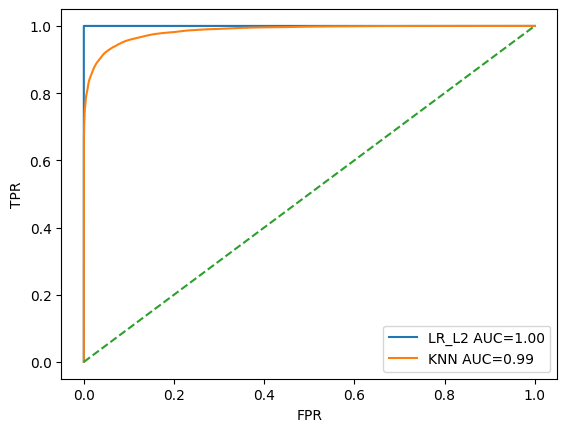

In [69]:
#ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure()

for name, (model, X_) in models.items():
    y_prob = model.predict_proba(X_)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


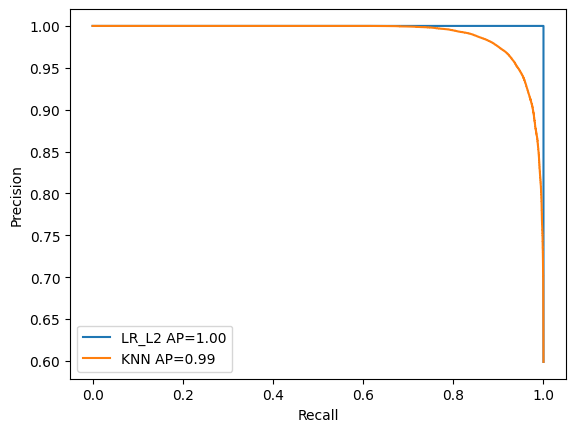

In [70]:
#Precision–Recall Curve + AP
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure()

for name, (model, X_) in models.items():
    y_prob = model.predict_proba(X_)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} AP={ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


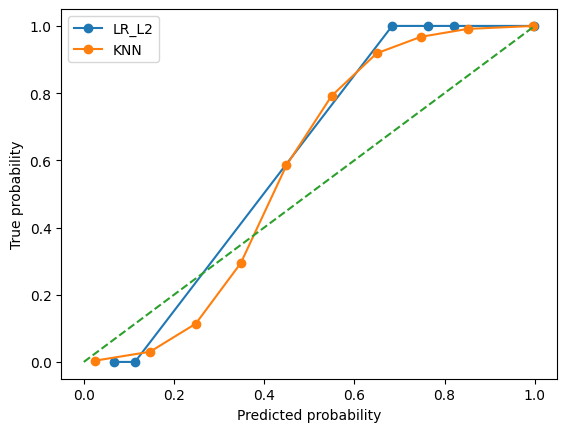

In [71]:
#Calibration Curve
from sklearn.calibration import calibration_curve

plt.figure()

for name, (model, X_) in models.items():
    y_prob = model.predict_proba(X_)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.legend()
plt.show()
